### IT Service Ticket SLA Breach Prediction


### Business Problem

An IT service-based company receives a large number of incidents and service requests from its clients.

Each ticket has an agreed Service Level Agreement (SLA) specifying how quickly it should be resolved.

Some tickets are resolved within the SLA, while others breach it.

The company wants to predict at the time a ticket is created whether it is likely to breach its SLA.

If a ticket is predicted as high-risk, the service management team can:

- Prioritize the ticket
- Assign an experienced engineer
- Escalate it
- Allocate additional resources
- Proactively communicate with the client

### ML Objective

This is a binary classification problem.
Our target will be:
SLA_Breached

- 0 → SLA will be met
- 1 → SLA will be breached

In [2]:
## Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# supress the warnings
import warnings
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv("../IT_Service_Ticket_SLA_Breach_Dataset.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,ticket_priority,ticket_category,ticket_source,customer_tier,customer_previous_tickets,customer_previous_breaches,engineer_experience_years,number_of_engineers_assigned,estimated_resolution_hours,number_of_dependencies,system_impact,business_impact,hour_created,day_of_week,is_weekend,SLA_Breached
0,0,Medium,Incident,Portal,Standard,5,1,9.2,2,13.1,2.0,Medium,Low,19,Thursday,0,1
1,1,Medium,Incident,Portal,Premium,10,1,14.4,2,13.1,1.0,Low,Medium,4,Sunday,0,0
2,2,Medium,Incident,Email,Premium,9,1,14.9,2,5.9,NaN,Low,Medium,6,Sunday,1,0
3,3,Medium,Incident,Portal,Premium,4,1,13.5,1,3.4,0.0,Medium,Medium,13,Wednesday,0,0
4,4,Medium,Service Request,Portal,Standard,10,1,12.8,1,6.9,3.0,Low,Low,4,Thursday,0,0


In [6]:
# Check number of rows and columns
print("Dataset shape:", df.shape)

# List all columns
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (5050, 17)

Columns:
['Unnamed: 0', 'ticket_priority', 'ticket_category', 'ticket_source', 'customer_tier', 'customer_previous_tickets', 'customer_previous_breaches', 'engineer_experience_years', 'number_of_engineers_assigned', 'estimated_resolution_hours', 'number_of_dependencies', 'system_impact', 'business_impact', 'hour_created', 'day_of_week', 'is_weekend', 'SLA_Breached']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    5050 non-null   int64  
 1   ticket_priority               5050 non-null   object 
 2   ticket_category               5050 non-null   object 
 3   ticket_source                 5050 non-null   object 
 4   customer_tier                 5050 non-null   object 
 5   customer_previous_tickets     5050 non-null   int64  
 6   customer_previous_breaches    5050 non-null   int64  
 7   engineer_experience_years     4899 non-null   float64
 8   number_of_engineers_assigned  5050 non-null   int64  
 9   estimated_resolution_hours    4900 non-null   float64
 10  number_of_dependencies        4898 non-null   float64
 11  system_impact                 5050 non-null   object 
 12  business_impact               5050 non-null   object 
 13  hou

In [8]:
# Basic statistical summary of numerical columns
df.describe()

,Unnamed: 0,customer_previous_tickets,customer_previous_breaches,engineer_experience_years,number_of_engineers_assigned,estimated_resolution_hours,number_of_dependencies,hour_created,is_weekend,SLA_Breached
count,5050.00000,5050.000000,5050.000000,4899.000000,5050.000000,4900.000000,4898.000000,5050.000000,5050.000000,5050.000000
mean,2524.50000,8.000000,1.208911,7.760604,1.670099,9.921735,1.991629,11.270693,0.286535,0.316040
std,1457.95376,2.798155,1.094884,4.163753,0.863464,6.331173,1.389939,6.967243,0.452187,0.464975
min,0.00000,0.000000,0.000000,0.500000,1.000000,0.400000,0.000000,0.000000,0.000000,0.000000
25%,1262.25000,6.000000,0.000000,4.100000,1.000000,5.300000,1.000000,5.000000,0.000000,0.000000
50%,2524.50000,8.000000,1.000000,7.900000,1.000000,8.600000,2.000000,11.000000,0.000000,0.000000
75%,3786.75000,10.000000,2.000000,11.400000,2.000000,13.200000,3.000000,17.000000,1.000000,1.000000
max,5049.00000,20.000000,7.000000,15.000000,4.000000,58.200000,12.000000,23.000000,1.000000,1.000000


In [11]:
# Check missing values in each column
missing_values = df.isnull().sum()
missing_values

Unnamed: 0                        0
ticket_priority                   0
ticket_category                   0
ticket_source                     0
customer_tier                     0
customer_previous_tickets         0
customer_previous_breaches        0
engineer_experience_years       151
number_of_engineers_assigned      0
estimated_resolution_hours      150
number_of_dependencies          152
system_impact                     0
business_impact                   0
hour_created                      0
day_of_week                       0
is_weekend                        0
SLA_Breached                      0
dtype: int64

In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Unnamed: 0                      0.000000
ticket_priority                 0.000000
ticket_category                 0.000000
ticket_source                   0.000000
customer_tier                   0.000000
customer_previous_tickets       0.000000
customer_previous_breaches      0.000000
engineer_experience_years       2.990099
number_of_engineers_assigned    0.000000
estimated_resolution_hours      2.970297
number_of_dependencies          3.009901
system_impact                   0.000000
business_impact                 0.000000
hour_created                    0.000000
day_of_week                     0.000000
is_weekend                      0.000000
SLA_Breached                    0.000000
dtype: float64

#### Missing values are within the limits of inputation

In [14]:
# Count duplicate rows

Duplicate_rows = df.duplicated().sum()
Duplicate_rows

0

#### No duplicate rows are present

#### Check unique values

In [16]:
df.nunique().sort_values()

SLA_Breached                       2
is_weekend                         2
business_impact                    3
system_impact                      3
customer_tier                      3
number_of_engineers_assigned       4
ticket_source                      4
ticket_category                    4
ticket_priority                    4
day_of_week                        7
customer_previous_breaches         8
number_of_dependencies            10
customer_previous_tickets         21
hour_created                      24
engineer_experience_years        146
estimated_resolution_hours       326
Unnamed: 0                      5050
dtype: int64

In [17]:
# unique values for categorical columns

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


ticket_priority:
['Medium' 'High' 'Critical' 'Low']

ticket_category:
['Incident' 'Service Request' 'Access' 'Problem']

ticket_source:
['Portal' 'Email' 'Phone' 'Monitoring']

customer_tier:
['Standard' 'Premium' 'Enterprise']

system_impact:
['Medium' 'Low' 'High']

business_impact:
['Low' 'Medium' 'High']

day_of_week:
['Thursday' 'Sunday' 'Wednesday' 'Friday' 'Monday' 'Saturday' 'Tuesday']


In [23]:
# Display frequency counts for categorical variables

for col in categorical_cols:
    print(f"\n-----------{col} --------")
    print(df[col].value_counts())


-----------ticket_priority --------
ticket_priority
Medium      1999
Low         1298
High        1269
Critical     484
Name: count, dtype: int64

-----------ticket_category --------
ticket_category
Incident           2605
Service Request    1260
Problem             701
Access              484
Name: count, dtype: int64

-----------ticket_source --------
ticket_source
Portal        2282
Email         1228
Phone         1026
Monitoring     514
Name: count, dtype: int64

-----------customer_tier --------
customer_tier
Standard      2446
Premium       1588
Enterprise    1016
Name: count, dtype: int64

-----------system_impact --------
system_impact
Low       2524
Medium    1726
High       800
Name: count, dtype: int64

-----------business_impact --------
business_impact
Low       2300
Medium    1736
High      1014
Name: count, dtype: int64

-----------day_of_week --------
day_of_week
Saturday     762
Thursday     749
Sunday       734
Friday       734
Wednesday    709
Tuesday      692
Mond

#### The categorical Data looks well balanced

In [25]:
# Numerical columns
numeric_cols = df.select_dtypes(include= ['int64', 'float64']).columns

print(numeric_cols)

Index(['Unnamed: 0', 'customer_previous_tickets', 'customer_previous_breaches',
       'engineer_experience_years', 'number_of_engineers_assigned',
       'estimated_resolution_hours', 'number_of_dependencies', 'hour_created',
       'is_weekend', 'SLA_Breached'],
      dtype='object')


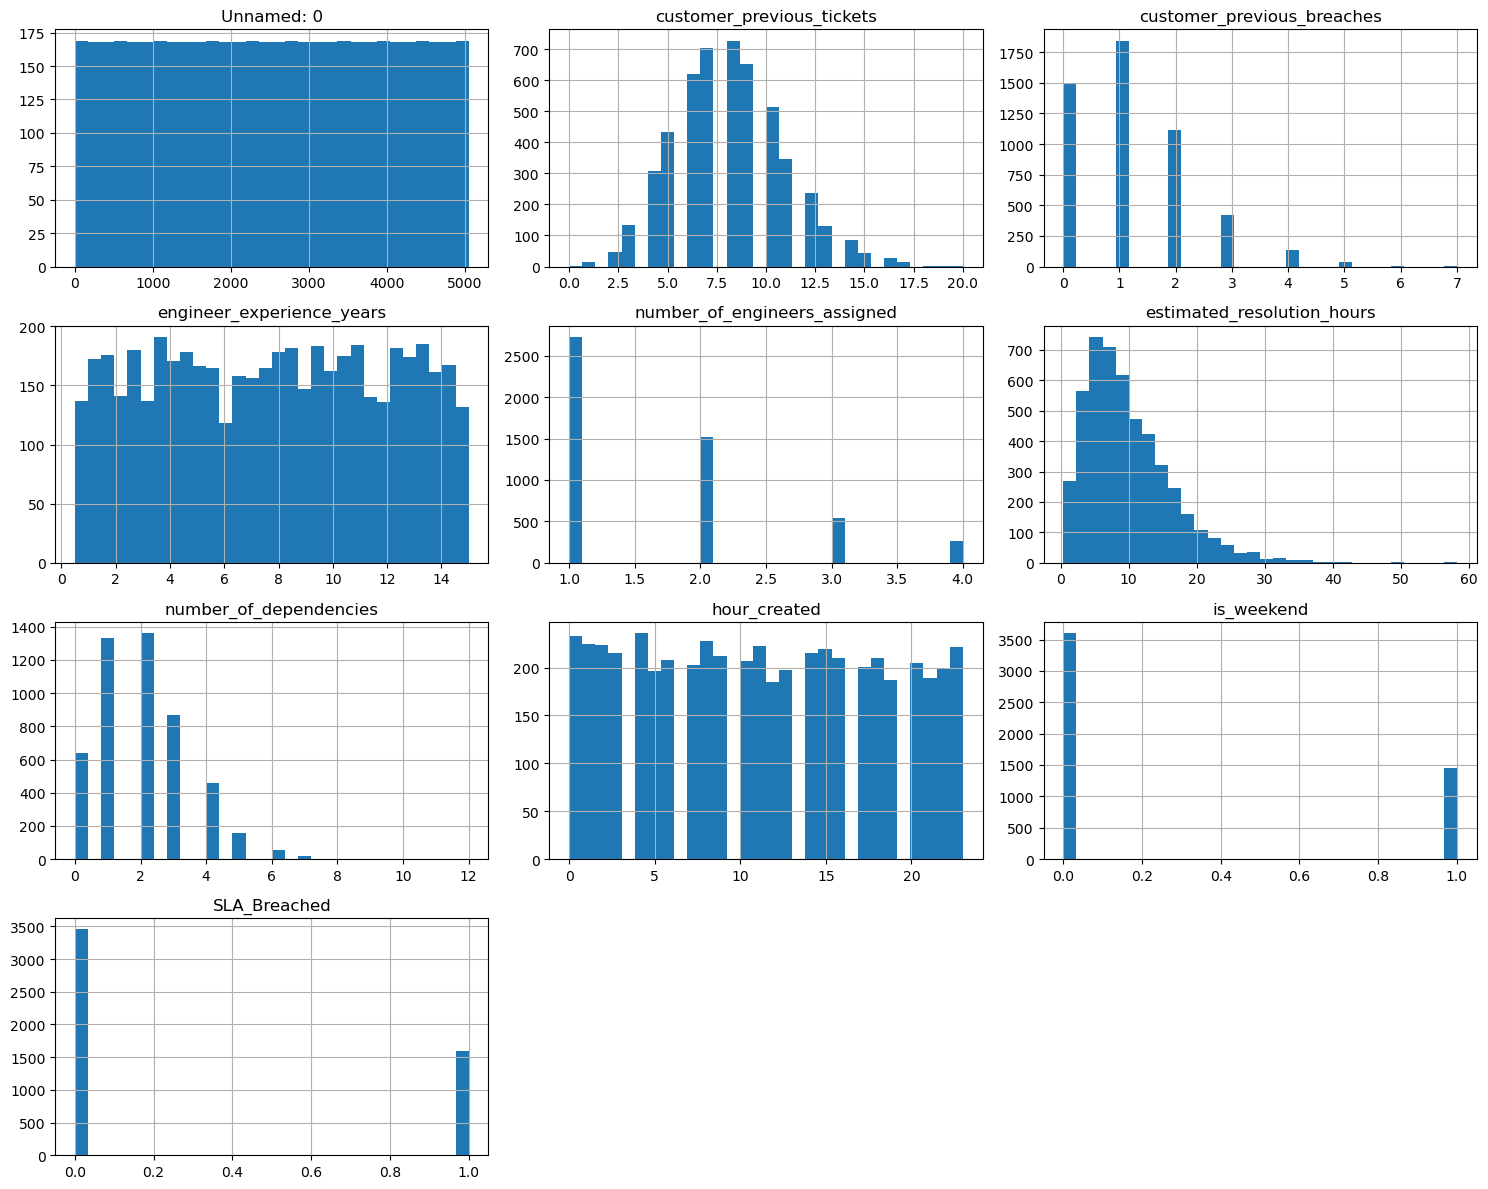

In [22]:
# Histograms for numerical variables

df[numeric_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

#### Checking Target variable

In [18]:
# Target class distribution

print(df["SLA_Breached"].value_counts())

SLA_Breached
0    3454
1    1596
Name: count, dtype: int64


In [19]:
# Target class percentage

print(df["SLA_Breached"].value_counts(normalize=True) * 100)

SLA_Breached
0    68.39604
1    31.60396
Name: proportion, dtype: float64


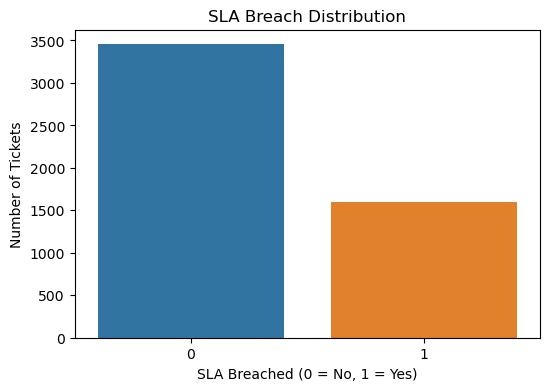

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="SLA_Breached")

plt.title("SLA Breach Distribution")
plt.xlabel("SLA Breached (0 = No, 1 = Yes)")
plt.ylabel("Number of Tickets")

plt.show()

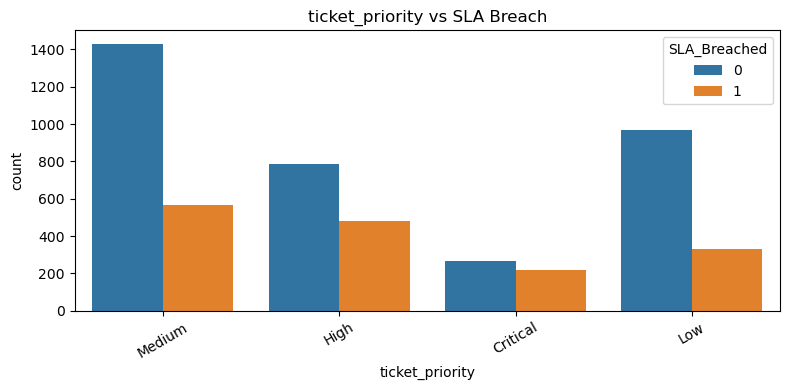

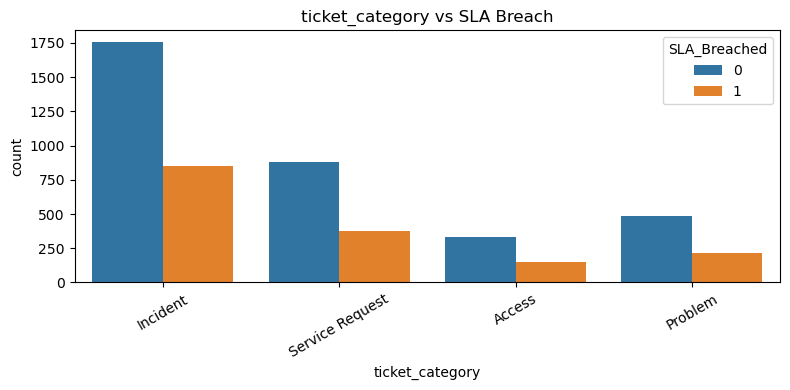

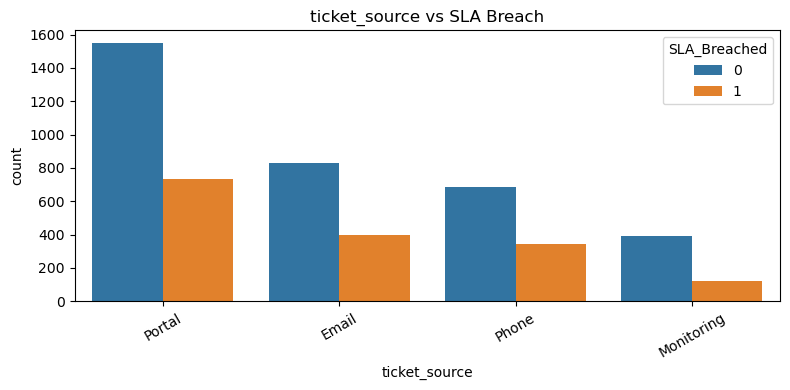

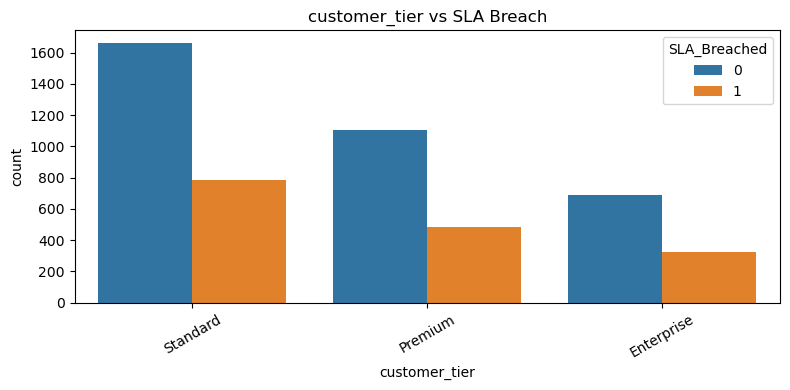

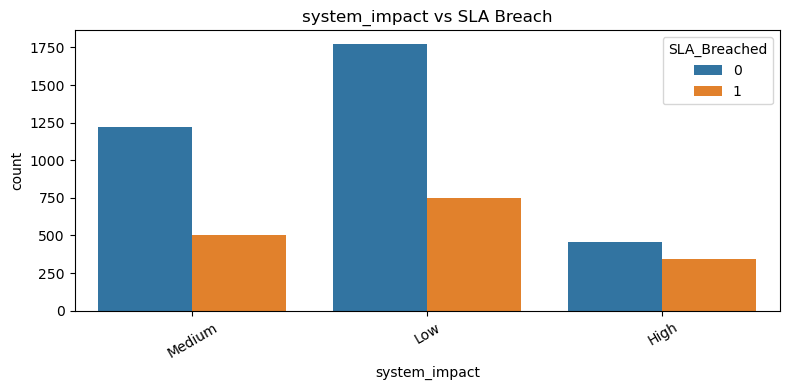

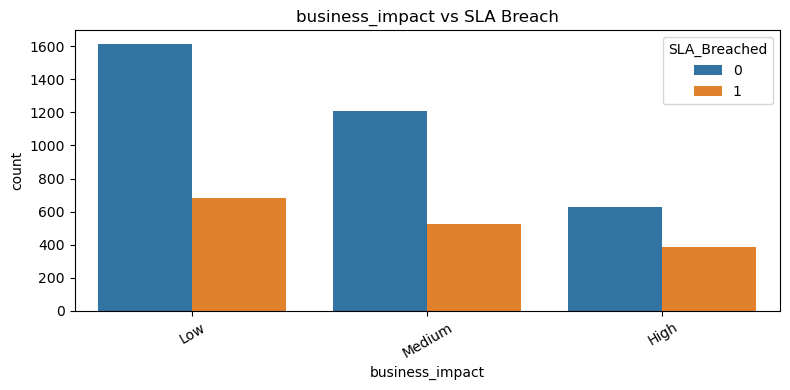

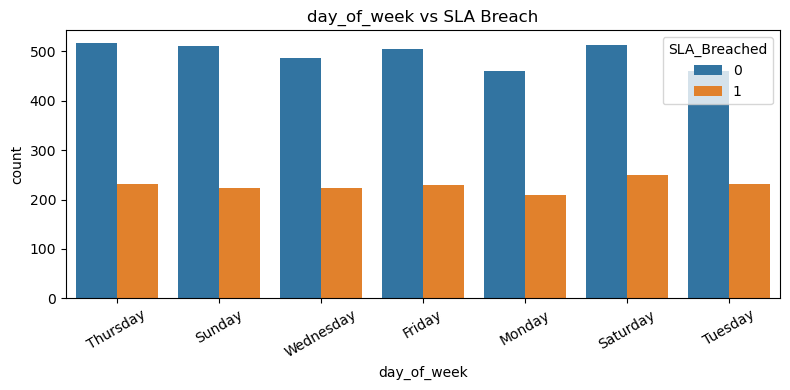

In [26]:
# Analyze categorical features against the target

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    
    sns.countplot(
        data=df,
        x=col,
        hue="SLA_Breached"
    )
    
    plt.title(f"{col} vs SLA Breach")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

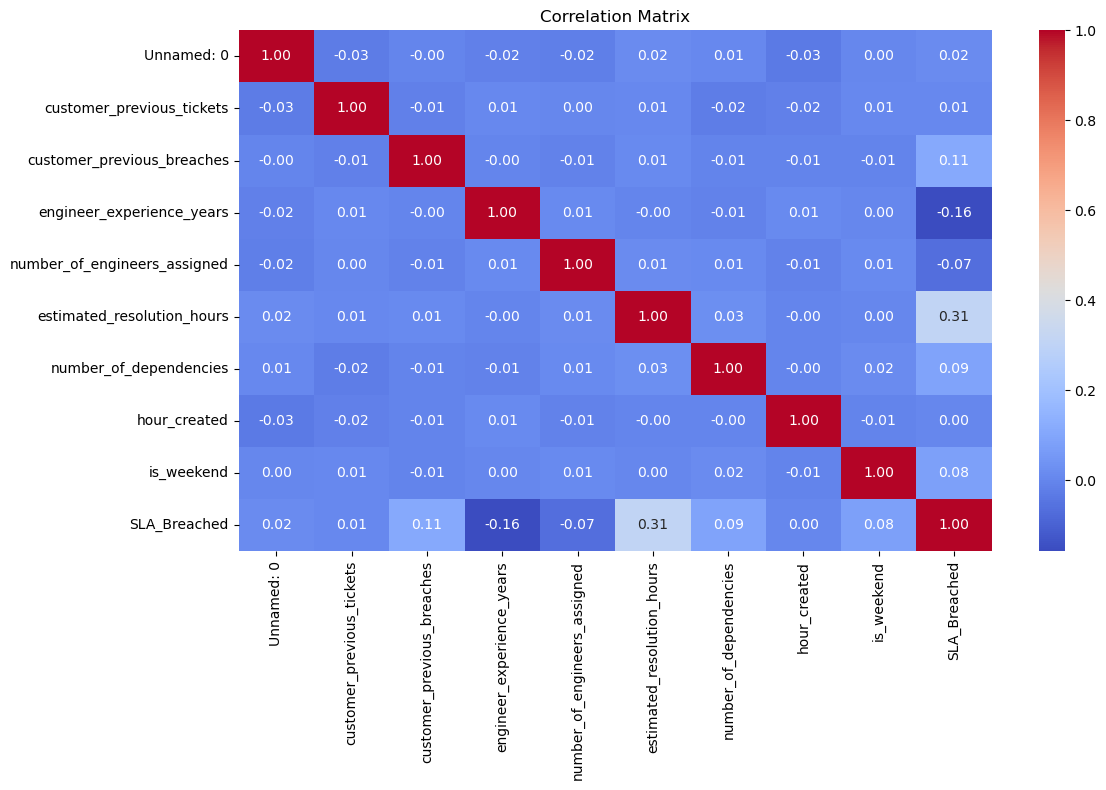

In [29]:
# Correlation matrix for numerical features

plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### no meaningful correlation is visible between teh numerical features